# Building Dashboards

In [29]:
import pandas as pd
import os
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style("dark",{"axes.facecolor":"black"})
%matplotlib inline

In [3]:
movies = pd.read_csv("C:/D/GitRepos/Python/PythonAZ/Section 6%3A Advanced Visualization/S6-Movie-Ratings.csv")
movies.columns=['Film', 'Genre', 'CriticRating', 'AudienceRating',
       'BudgetMillions', 'Year']
movies.Film=movies.Film.astype('category')
movies.Genre=movies.Genre.astype('category')
movies.Year=movies.Year.astype('category')
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 559 entries, 0 to 558
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Film            559 non-null    category
 1   Genre           559 non-null    category
 2   CriticRating    559 non-null    int64   
 3   AudienceRating  559 non-null    int64   
 4   BudgetMillions  559 non-null    int64   
 5   Year            559 non-null    category
dtypes: category(3), int64(3)
memory usage: 36.5 KB


In [4]:
movies.describe()

,CriticRating,AudienceRating,BudgetMillions
count,559.000000,559.000000,559.000000
mean,47.309481,58.744186,50.236136
std,26.413091,16.826887,48.731817
min,0.000000,0.000000,0.000000
25%,25.000000,47.000000,20.000000
50%,46.000000,58.000000,35.000000
75%,70.000000,72.000000,65.000000
max,97.000000,96.000000,300.000000


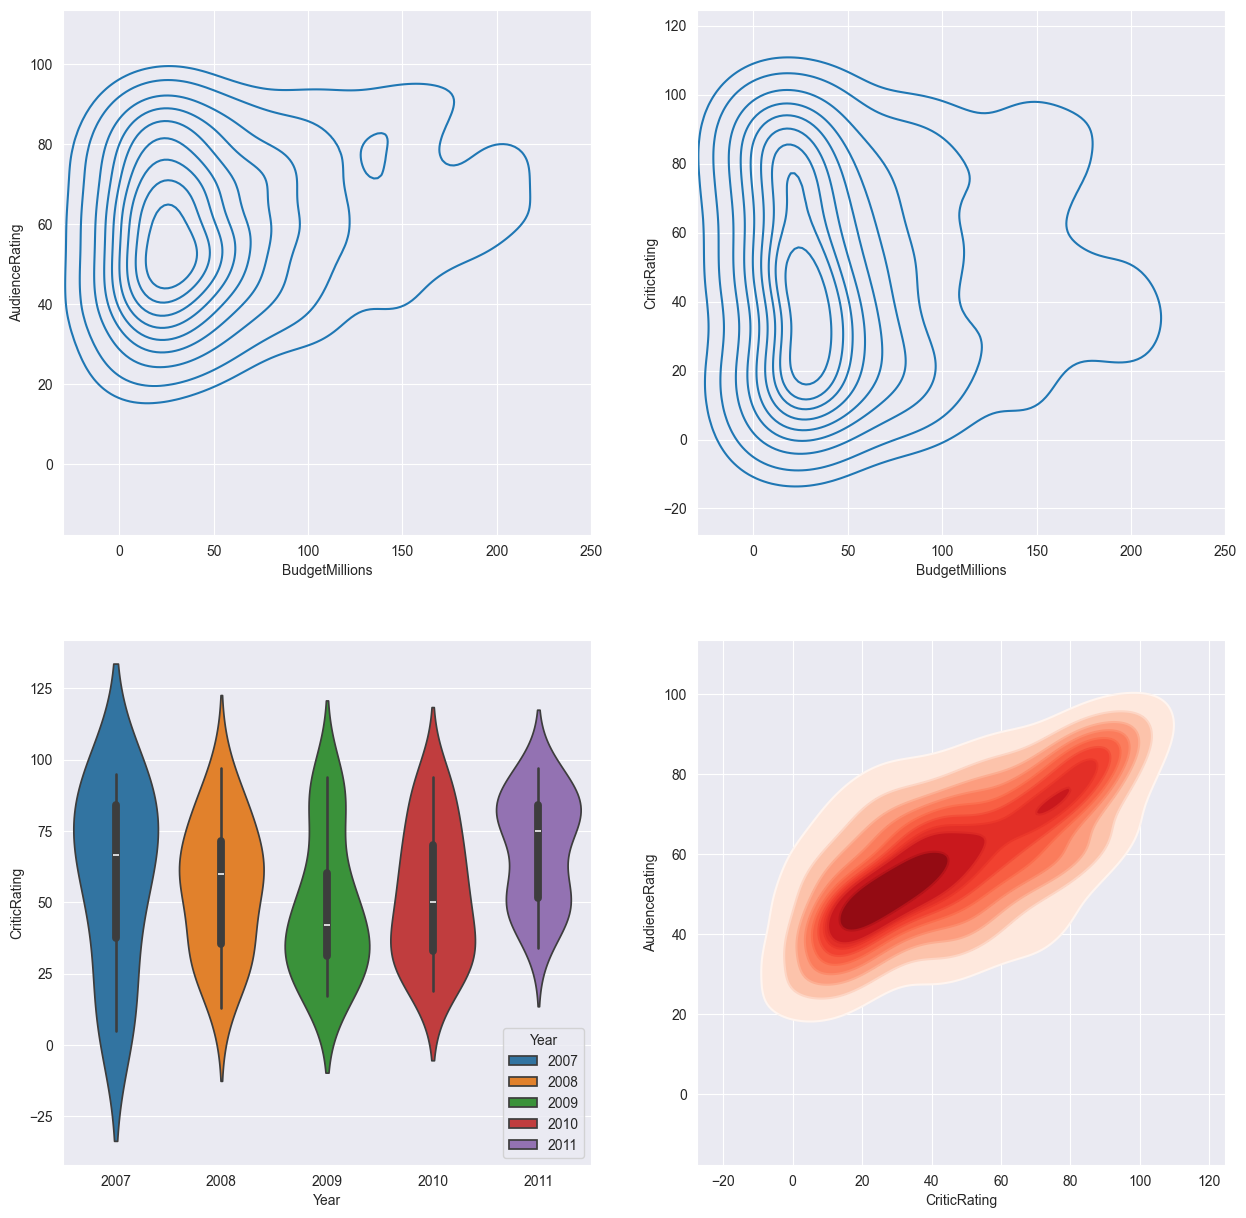

In [5]:
f, axes = plt.subplots(2,2,figsize=(15,15))
k1 = sns.kdeplot(x=movies.BudgetMillions, y=movies.AudienceRating,ax=axes[0,0])
k2 = sns.kdeplot(x=movies.BudgetMillions, y=movies.CriticRating,ax=axes[0,1])
k1.set(xlim=(-30,250))
k2.set(xlim=(-30,250))
k3 = sns.violinplot(data=movies[movies.Genre=='Drama'], x='Year', y='CriticRating',hue='Year', ax=axes[1,0])
k4=sns.kdeplot(x=movies.CriticRating,y=movies.AudienceRating,fill=True,cmap='Reds',thresh=0.05, ax=axes[1,1])
k4b=sns.kdeplot(x=movies.CriticRating,y=movies.AudienceRating,cmap='Reds', ax=axes[1,1])  # adding edges
plt.show()

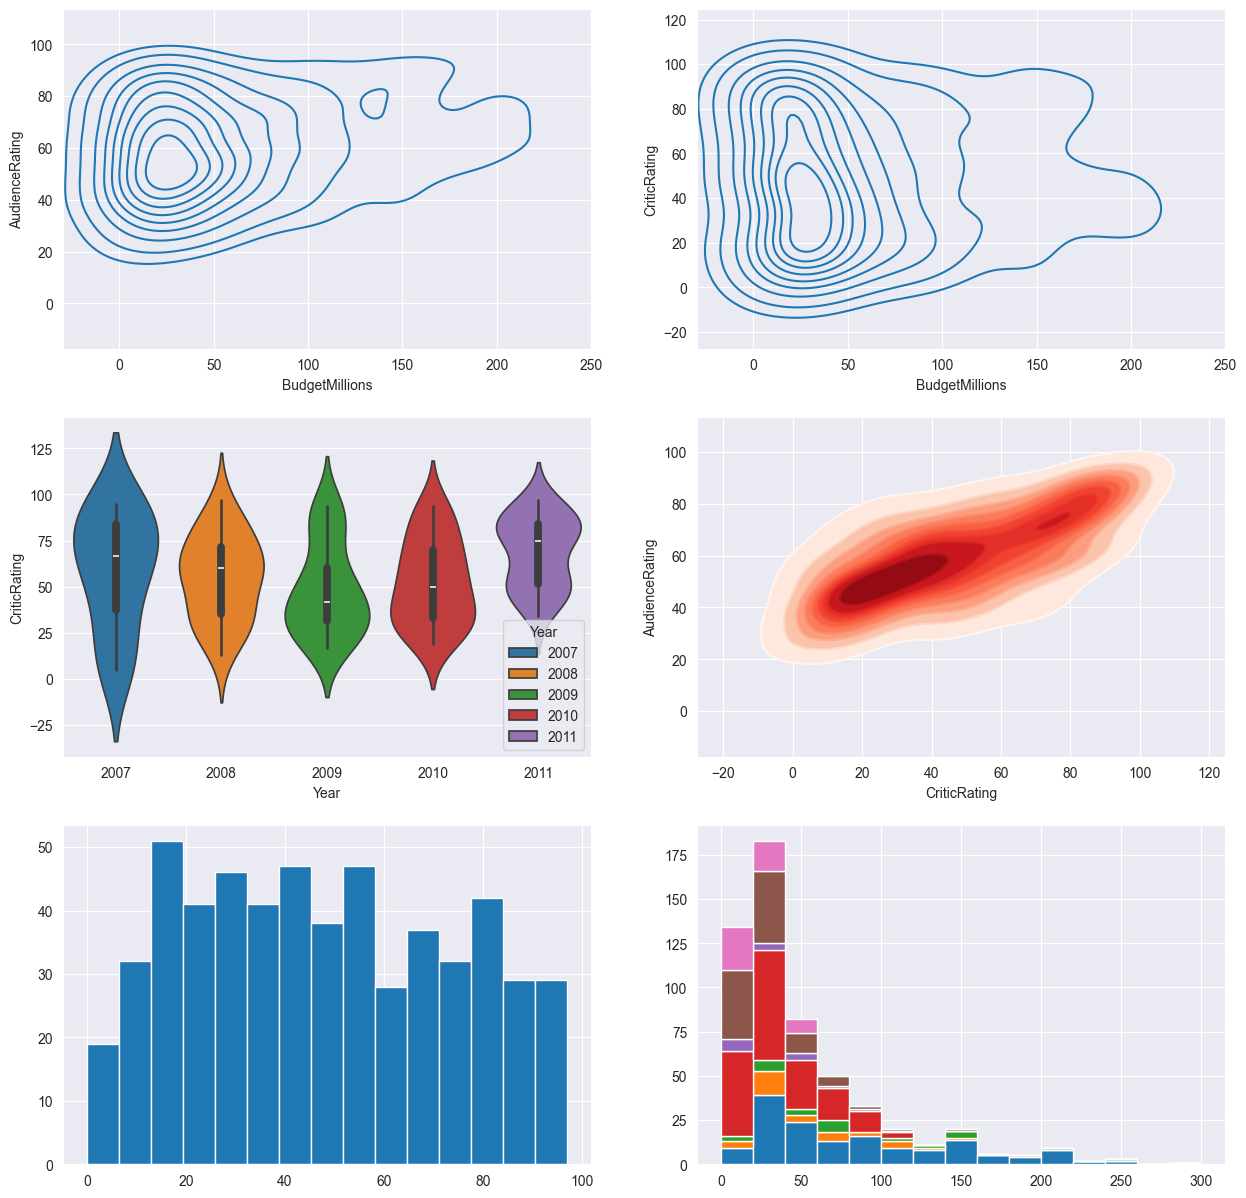

In [6]:
# let's add pyplot graphs into the dashboard, to see that we could use pyplot graphs if needed
f, axes = plt.subplots(3,2,figsize=(15,15))  # We add one more row
k1 = sns.kdeplot(x=movies.BudgetMillions, y=movies.AudienceRating,ax=axes[0,0])
k2 = sns.kdeplot(x=movies.BudgetMillions, y=movies.CriticRating,ax=axes[0,1])
k1.set(xlim=(-30,250))
k2.set(xlim=(-30,250))
k3 = sns.violinplot(data=movies[movies.Genre=='Drama'], x='Year', y='CriticRating',hue='Year', ax=axes[1,0])
k4=sns.kdeplot(x=movies.CriticRating,y=movies.AudienceRating,fill=True,cmap='Reds',thresh=0.05, ax=axes[1,1])
k4b=sns.kdeplot(x=movies.CriticRating,y=movies.AudienceRating,cmap='Reds', ax=axes[1,1])  # adding edges
# Now we populate the third row with pyplot graphs
axes[2,0].hist(movies.CriticRating,bins=15)
axes[2,1].hist([movies[movies.Genre=='Action'].BudgetMillions,movies[movies.Genre=='Thriller'].BudgetMillions,movies[movies.Genre=='Adventure'].BudgetMillions, \
          movies[movies.Genre=='Comedy'].BudgetMillions,movies[movies.Genre=='Romance'].BudgetMillions,movies[movies.Genre=='Drama'].BudgetMillions, \
          movies[movies.Genre=='Horror'].BudgetMillions], bins=15, stacked=True)
plt.show()

## Styling dashboards

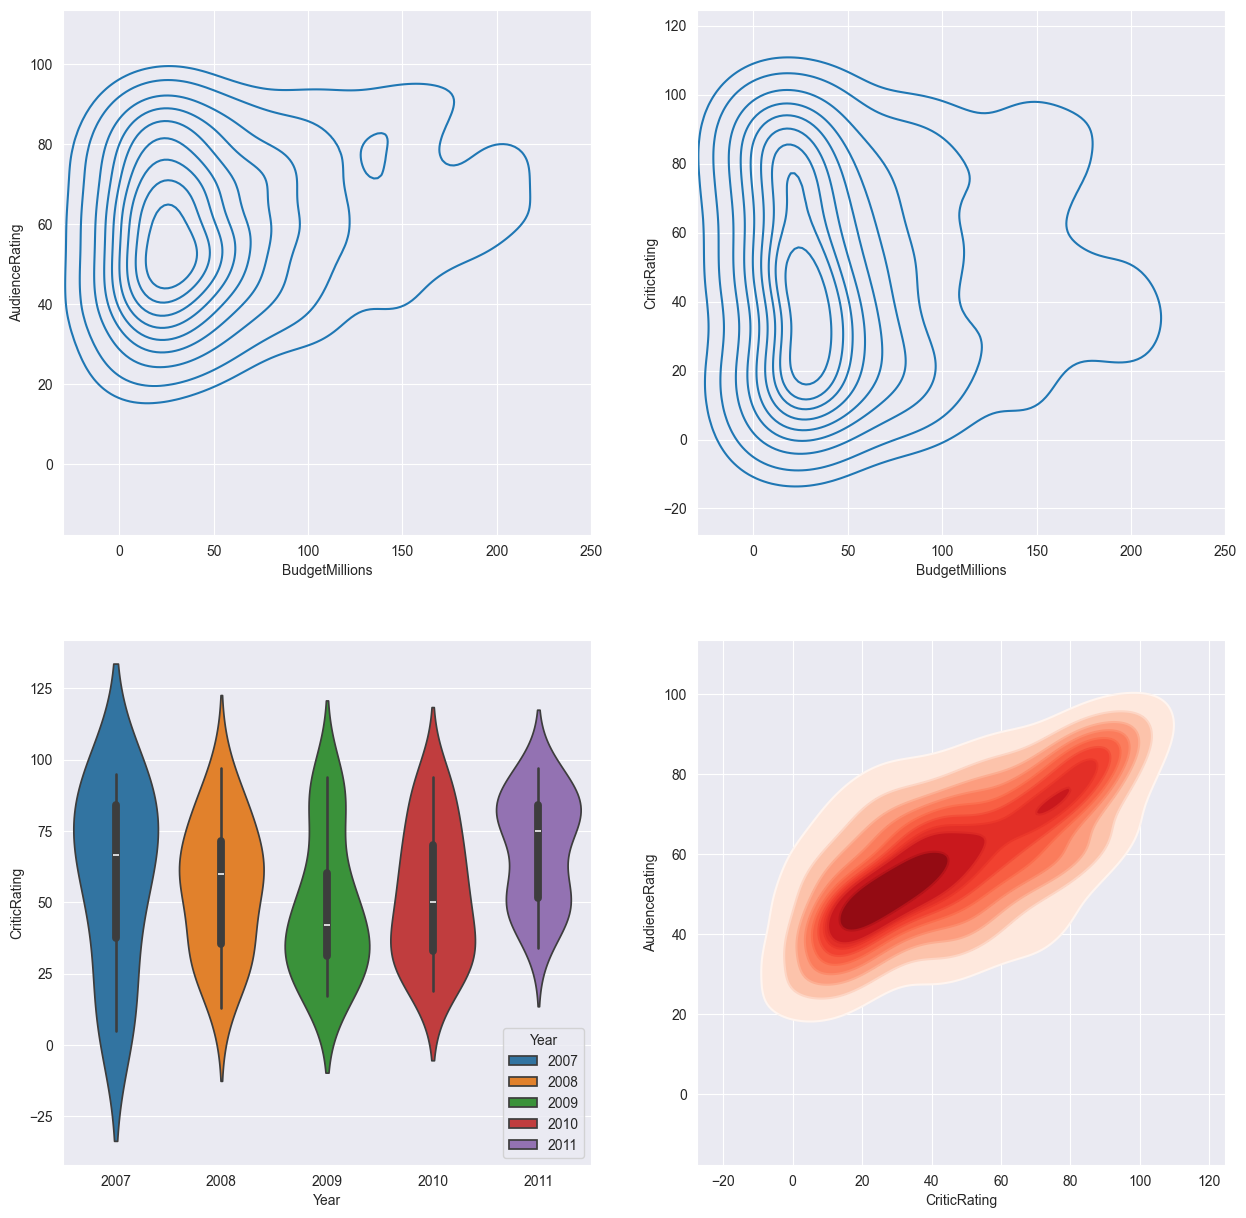

In [7]:
f, axes = plt.subplots(2,2,figsize=(15,15))
k1 = sns.kdeplot(x=movies.BudgetMillions, y=movies.AudienceRating,ax=axes[0,0])
k2 = sns.kdeplot(x=movies.BudgetMillions, y=movies.CriticRating,ax=axes[0,1])
k1.set(xlim=(-30,250))
k2.set(xlim=(-30,250))
k3 = sns.violinplot(data=movies[movies.Genre=='Drama'], x='Year', y='CriticRating',hue='Year', ax=axes[1,0])
k4=sns.kdeplot(x=movies.CriticRating,y=movies.AudienceRating,fill=True,cmap='Reds',thresh=0.05, ax=axes[1,1])
k4b=sns.kdeplot(x=movies.CriticRating,y=movies.AudienceRating,cmap='Reds', ax=axes[1,1])  # adding edges
plt.show()

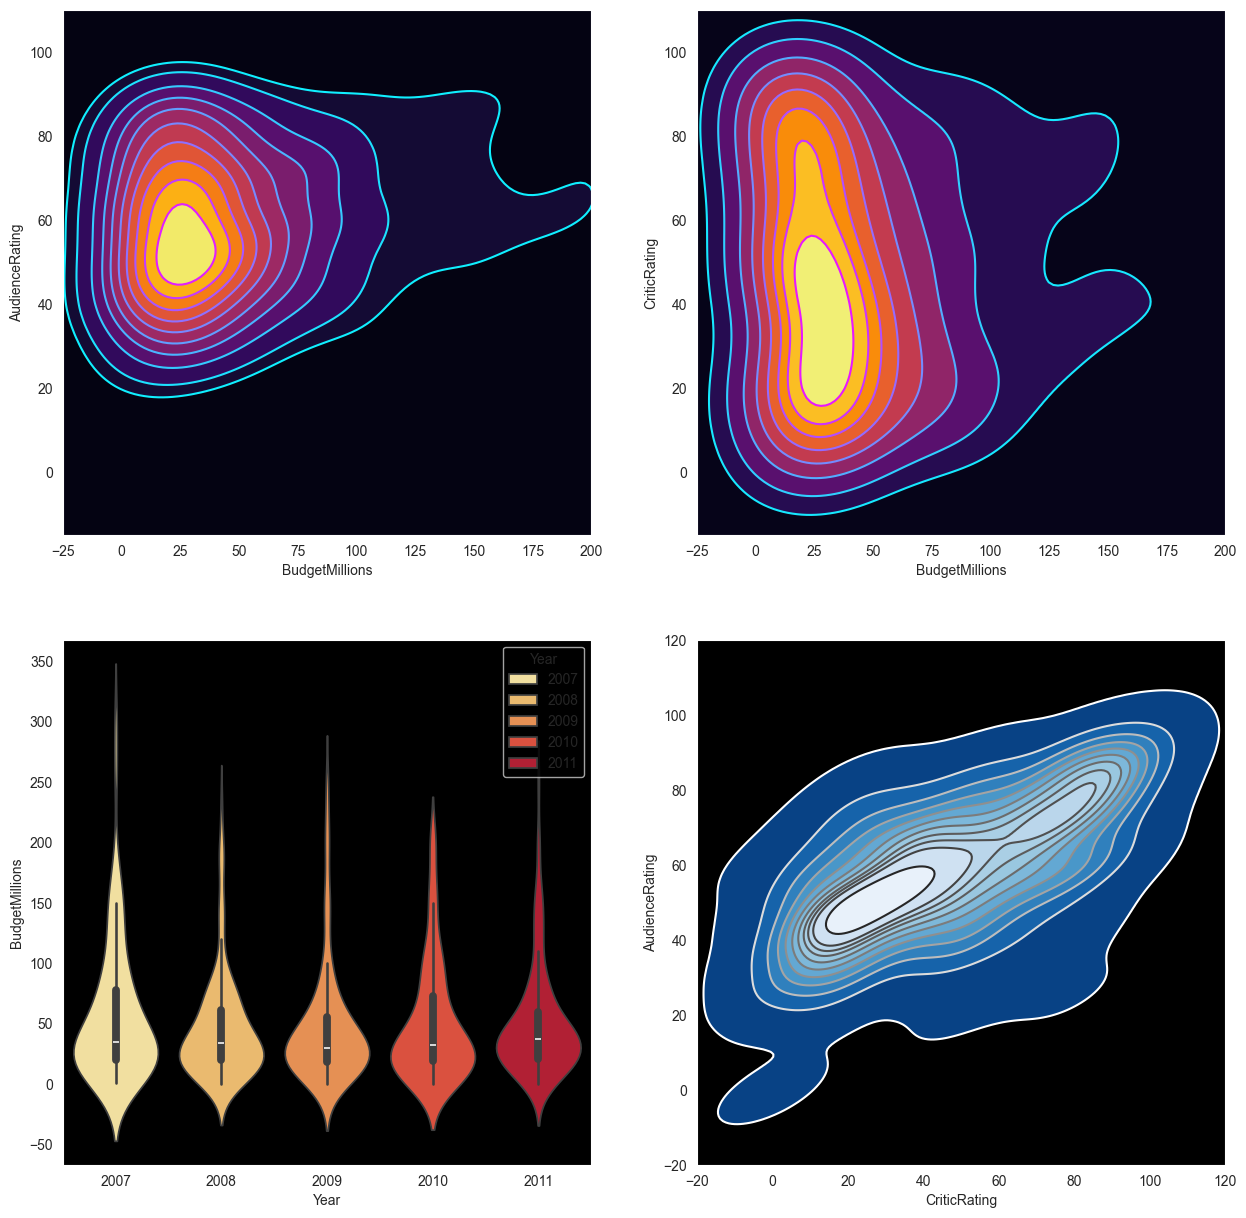

In [36]:
f, axes = plt.subplots(2,2,figsize=(15,15))
k1 = sns.kdeplot(x=movies.BudgetMillions, y=movies.AudienceRating,thresh=0.0,fill=True,levels=12,cmap='inferno',ax=axes[0,0])
k1b= sns.kdeplot(x=movies.BudgetMillions, y=movies.AudienceRating,thresh=0.0,fill=False,levels=12,cmap='cool',ax=axes[0,0])  # adding edges
k1.set(xlim=(-25,200))
k1.set(ylim=(-15,110))

k2 = sns.kdeplot(x=movies.BudgetMillions, y=movies.CriticRating,thresh=0,fill=True,cmap='inferno',ax=axes[0,1])
k2b= sns.kdeplot(x=movies.BudgetMillions, y=movies.CriticRating,thresh=0,fill=False,cmap='cool',ax=axes[0,1])  # adding edges
k2.set(xlim=(-25,200))
k2.set(ylim=(-15,110))

k3 = sns.violinplot(data=movies, x='Year', y='BudgetMillions',hue='Year', ax=axes[1,0], palette='YlOrRd')

k4 = sns.kdeplot(x=movies.CriticRating,y=movies.AudienceRating,thresh=0.005,fill=True,levels=12,cmap='Blues_r', ax=axes[1,1])
k4b= sns.kdeplot(x=movies.CriticRating,y=movies.AudienceRating,thresh=0.005,fill=False,levels=12,cmap='gist_gray_r', ax=axes[1,1])  # adding edges
k4.set(xlim=(-20,120))
k4.set(ylim=(-20,120))

plt.show() 

# Finishing touches

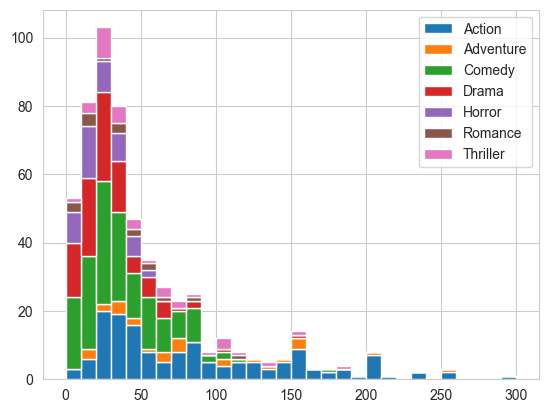

In [39]:
# Remove black background
sns.set_style("whitegrid")
# Start from this chart
list1 = list()
labels = list()
for gen in movies.Genre.cat.categories:
    list1.append(movies[movies.Genre == gen].BudgetMillions)
    labels.append(gen)

h = plt.hist(list1, bins=30,stacked=True,rwidth=1,label=labels)
plt.legend()
plt.show()

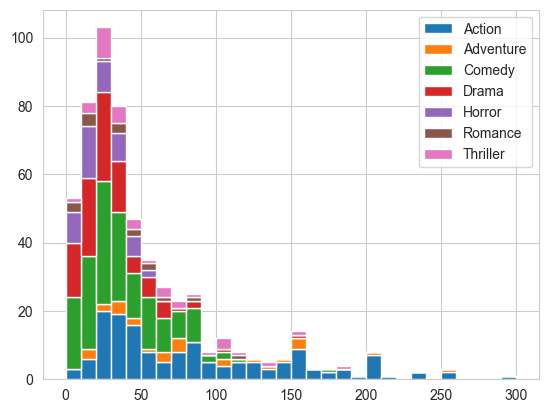

In [40]:
# Size by creatin subplots with only one item
list1 = list()
labels = list()
for gen in movies.Genre.cat.categories:
    list1.append(movies[movies.Genre == gen].BudgetMillions)
    labels.append(gen)

fig, ax = plt.subplots() # with no parameters, creates only one subplot
h = plt.hist(list1, bins=30,stacked=True,rwidth=1,label=labels)
plt.legend()
plt.show()

In [ ]:
#Now we can change the size in the way we know

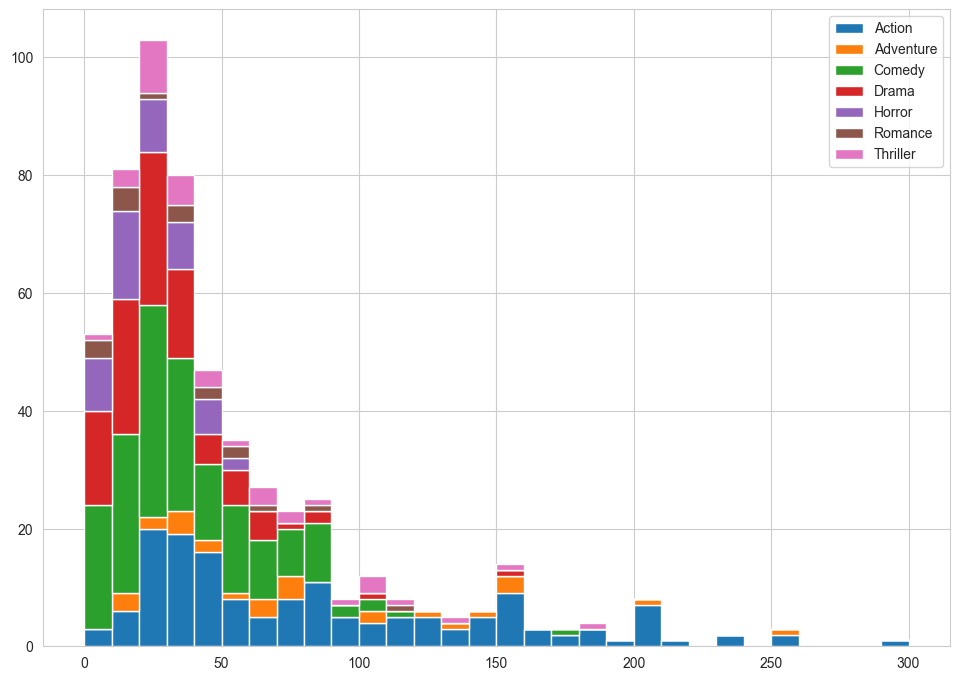

In [41]:
list1 = list()
labels = list()
for gen in movies.Genre.cat.categories:
    list1.append(movies[movies.Genre == gen].BudgetMillions)
    labels.append(gen)

fig, ax = plt.subplots() # with no parameters, creates only one subplot
fig.set_size_inches(11.7,8.27) # size A4
h = plt.hist(list1, bins=30,stacked=True,rwidth=1,label=labels)
plt.legend()
plt.show()

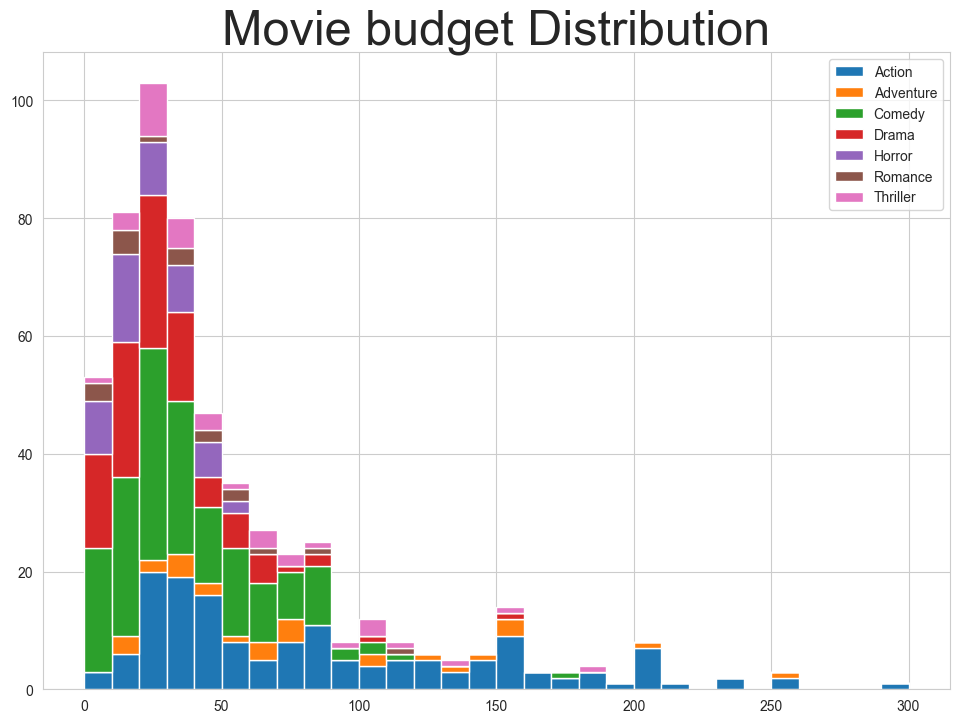

In [43]:
#Title
list1 = list()
labels = list()
for gen in movies.Genre.cat.categories:
    list1.append(movies[movies.Genre == gen].BudgetMillions)
    labels.append(gen)

fig, ax = plt.subplots() # with no parameters, creates only one subplot
fig.set_size_inches(11.7,8.27) # size A4
h = plt.hist(list1, bins=30,stacked=True,rwidth=1,label=labels)
plt.title("Movie budget Distribution", fontsize=35)
plt.legend()
plt.show()


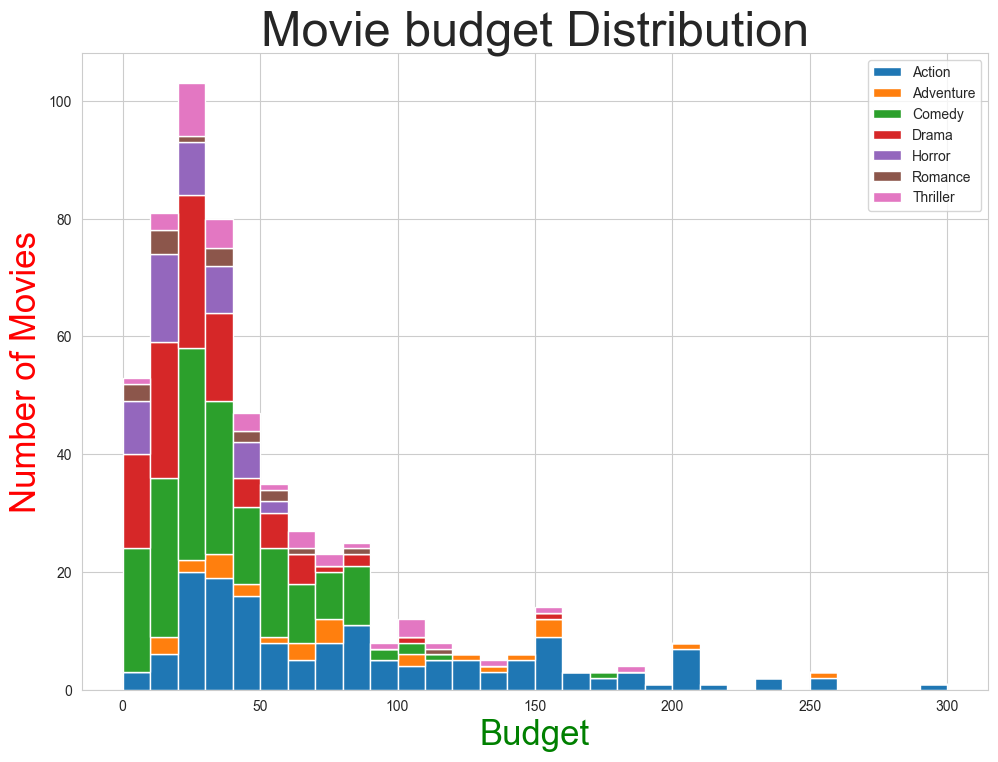

In [44]:
#Labels for axes
list1 = list()
labels = list()
for gen in movies.Genre.cat.categories:
    list1.append(movies[movies.Genre == gen].BudgetMillions)
    labels.append(gen)

fig, ax = plt.subplots() # with no parameters, creates only one subplot
fig.set_size_inches(11.7,8.27) # size A4
h = plt.hist(list1, bins=30,stacked=True,rwidth=1,label=labels)
plt.title("Movie budget Distribution", fontsize=35)
plt.ylabel("Number of Movies", fontsize=25, color='Red')
plt.xlabel("Budget", fontsize=25, color='Green')
plt.legend()
plt.show()


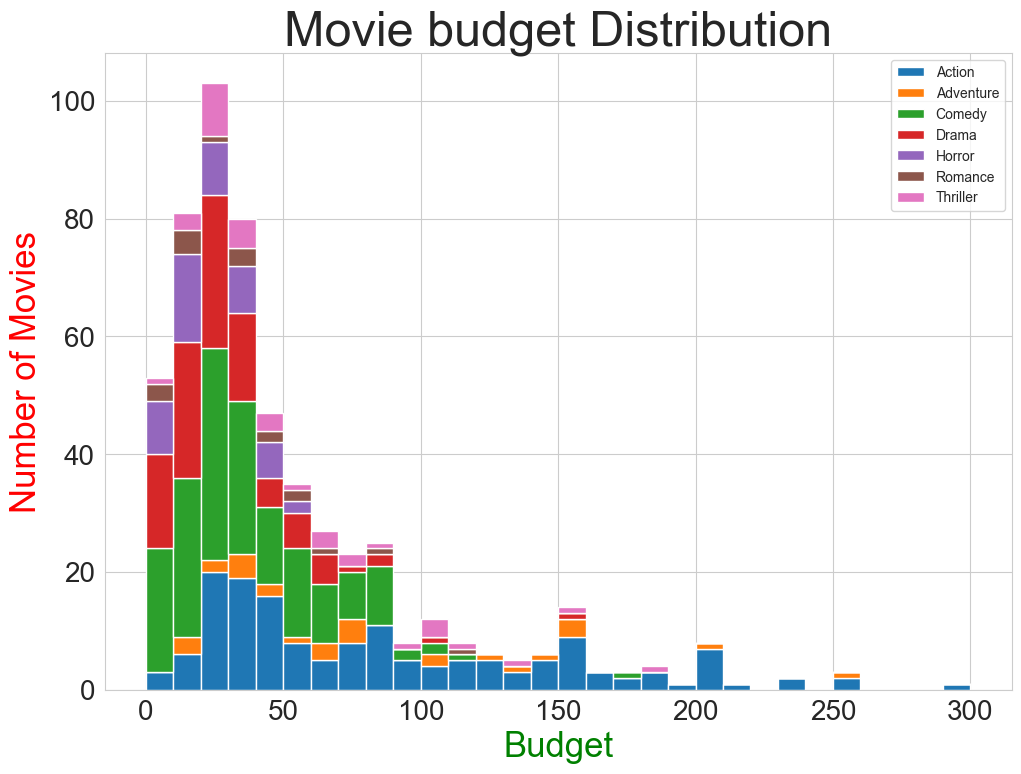

In [45]:
#Ticks on the axis and their font
list1 = list()
labels = list()
for gen in movies.Genre.cat.categories:
    list1.append(movies[movies.Genre == gen].BudgetMillions)
    labels.append(gen)

fig, ax = plt.subplots() # with no parameters, creates only one subplot
fig.set_size_inches(11.7,8.27) # size A4
h = plt.hist(list1, bins=30,stacked=True,rwidth=1,label=labels)
plt.title("Movie budget Distribution", fontsize=35)
plt.ylabel("Number of Movies", fontsize=25, color='Red')
plt.xlabel("Budget", fontsize=25, color='Green')
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.legend()
plt.show()

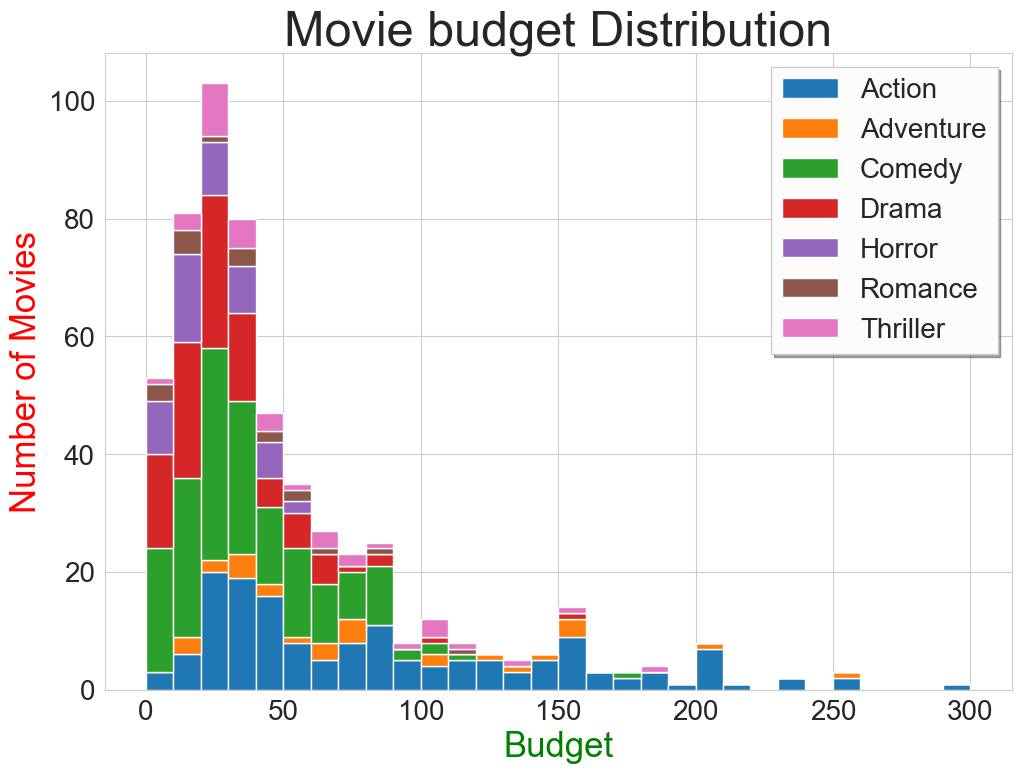

In [50]:
#Legend font size and styling
list1 = list()
labels = list()
for gen in movies.Genre.cat.categories:
    list1.append(movies[movies.Genre == gen].BudgetMillions)
    labels.append(gen)

fig, ax = plt.subplots() # with no parameters, creates only one subplot
fig.set_size_inches(11.7,8.27) # size A4
h = plt.hist(list1, bins=30,stacked=True,rwidth=1,label=labels)
plt.title("Movie budget Distribution", fontsize=35)
plt.ylabel("Number of Movies", fontsize=25, color='Red')
plt.xlabel("Budget", fontsize=25, color='Green')
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.legend(frameon=True, fancybox=False, shadow=True, framealpha=0.98, prop={'size':20})
plt.show()

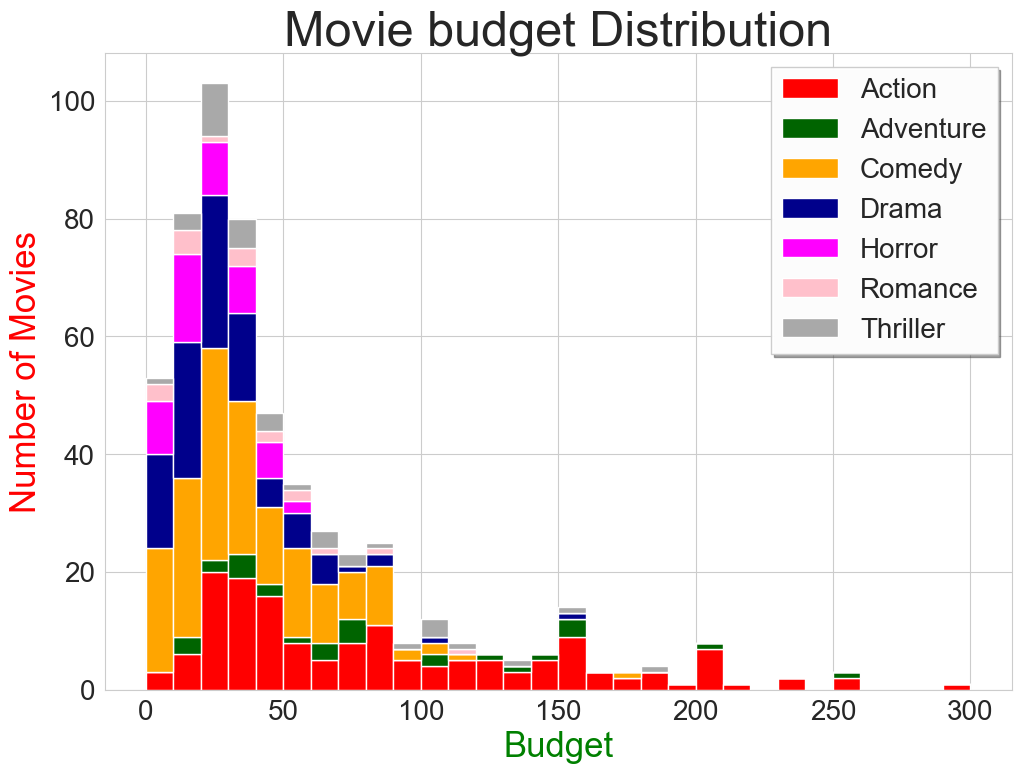

In [55]:
#Change the default assigned colors
list1 = list()
labels = list()
for gen in movies.Genre.cat.categories:
    list1.append(movies[movies.Genre == gen].BudgetMillions)
    labels.append(gen)

fig, ax = plt.subplots() # with no parameters, creates only one subplot
fig.set_size_inches(11.7,8.27) # size A4
h = plt.hist(list1, bins=30,stacked=True,rwidth=1,label=labels, color=['Red', 'DarkGreen','Orange','DarkBlue','Magenta','Pink','DarkGrey'])
plt.title("Movie budget Distribution", fontsize=35)
plt.ylabel("Number of Movies", fontsize=25, color='Red')
plt.xlabel("Budget", fontsize=25, color='Green')
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.legend(frameon=True, fancybox=False, shadow=True, framealpha=0.98, prop={'size':20})
plt.show()

In [53]:
movies.Genre.unique()

['Comedy', 'Adventure', 'Action', 'Horror', 'Drama', 'Romance', 'Thriller']
Categories (7, object): ['Action', 'Adventure', 'Comedy', 'Drama', 'Horror', 'Romance', 'Thriller']